In [1]:
from pathlib import Path
from typing import TYPE_CHECKING, cast

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

if TYPE_CHECKING:
    from cartopy.mpl.geoaxes import GeoAxes

In [2]:
FIG_SAVE_FMT = "png"

In [3]:
NOTEBOOK_DIR = Path().cwd().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"

INNER_NITRATE_PATH = (
    DATA_DIR / "CE01ISSP/CE01ISSP_nitrate_binned_baseline_subtracted_2014-04-17_2023-09-17_with_dndt_resampled.nc"
)
MIDSHELF_NITRATE_PATH = (
    DATA_DIR / "CE02SHSP/CE02SHSP_nitrate_binned_baseline_subtracted_2015-03-18_2024-07-14_with_dndt_resampled.nc"
)
WIND_PATH = DATA_DIR / "NDBC_46050/46050_wind_binned_with_w5d_w8d.nc"

OPTAA_PATH = DATA_DIR / "CE01ISSM/ce01issm_optaa_processed.nc"
FLORT_PATH = DATA_DIR / "CE01ISSM/ce01issm_flort_processed.nc"

VEL_PATH = DATA_DIR / "NH10_Mooring_Data/nh10_hourly_data_1997_2023_rotated_filtered_streamwise_v4.nc"
OLD_VEL_PATH = list(
    Path(DATA_DIR / "NH10_Mooring_Data/").glob("nh10_hourly_data_1997_2021_part*.nc"),
)
NEW_VEL_PATH = DATA_DIR / "NH10_Mooring_Data/ADCP_NH10_1997_2024_V5.nc"

VELOCITY_VARIABLE = "cs"

In [4]:
MIN_VEL_DEPTH = 10  # meters
MAX_VEL_DEPTH = 80  # meters

inner_nitrate = xr.open_dataset(INNER_NITRATE_PATH)
midshelf_nitrate = xr.open_dataset(MIDSHELF_NITRATE_PATH)
wind = xr.open_dataset(WIND_PATH, decode_timedelta=True)
velocity = xr.open_dataset(VEL_PATH)
optaa = xr.open_dataset(OPTAA_PATH)
flort = xr.open_dataset(FLORT_PATH)

# bit of a lazy way to use the cs_proj variable, since the notebook is set up for cs
if VELOCITY_VARIABLE == "cs_proj":
    velocity = velocity.drop_vars("cs").rename({"cs_proj": "cs"})

inner_nitrate = inner_nitrate.resample(time="1D").mean()

# resample midshelf nitrate to fill some of the gaps for composite calclulations
midshelf_nitrate = midshelf_nitrate.resample(time="1D").mean()

# interpolate velocity depths to match 1 meter bins in midshelf nitrate
velocity = velocity.interp(depth=midshelf_nitrate.depth)
velocity = velocity.resample(time="1D").mean()
velocity = velocity.where((velocity.depth > MIN_VEL_DEPTH) & (velocity.depth < MAX_VEL_DEPTH))

flort = flort.drop_dims("stats")
optaa_al, flort_al = xr.align(
    optaa.drop_duplicates("time"),
    flort.drop_duplicates("time"),
)

estimated_chloro = (optaa_al.estimated_chlorophyll + flort_al.estimated_chlorophyll) / 2
estimated_chloro = estimated_chloro.resample(time="1D").mean()

nhl_grid = xr.load_dataset(
    "../data/NHL_Gridded/newport_hydrographic_line_gridded_sections.nc",
).squeeze()

In [5]:
chloro_data_resampled = estimated_chloro.resample(time="1D").mean()

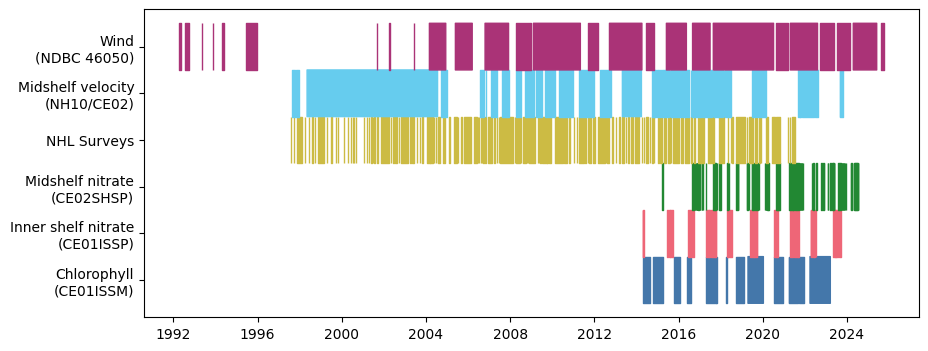

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax = cast(plt.Axes, ax)

wind_data_avail = wind["w8d"].notnull()
chloro_data_avail = estimated_chloro.notnull()
vel_data_avail = velocity["cs"].notnull().any(dim="depth")
inner_nitrate_data_avail = inner_nitrate.nitrate.notnull().any(dim="depth")
midshelf_nitrate_data_avail = midshelf_nitrate.nitrate.notnull().any(dim="depth")
nhl_grid_data_avail = nhl_grid["potential_density"].notnull().any("pressure").isel(longitude=0)

ax.fill_between(
    chloro_data_avail.time,
    chloro_data_avail - 0.5,
    chloro_data_avail + 0.5,
    where=chloro_data_avail,
    step="mid",
    color="#4477AA",
)
ax.fill_between(
    inner_nitrate_data_avail.time,
    inner_nitrate_data_avail + 0.5,
    inner_nitrate_data_avail + 1.5,
    where=inner_nitrate_data_avail,
    step="mid",
    color="#EE6677",
)
ax.fill_between(
    midshelf_nitrate_data_avail.time,
    midshelf_nitrate_data_avail + 1.5,
    midshelf_nitrate_data_avail + 2.5,
    where=midshelf_nitrate_data_avail,
    step="mid",
    color="#228833",
)
ax.fill_between(
    nhl_grid_data_avail.time,
    nhl_grid_data_avail + 2.5,
    nhl_grid_data_avail + 3.5,
    where=nhl_grid_data_avail,
    step="mid",
    color="#CCBB44",
)
ax.fill_between(
    vel_data_avail.time,
    vel_data_avail + 3.5,
    vel_data_avail + 4.5,
    where=vel_data_avail,
    step="mid",
    color="#66CCEE",
)
ax.fill_between(
    wind_data_avail.time,
    wind_data_avail + 4.5,
    wind_data_avail + 5.5,
    where=wind_data_avail,
    step="mid",
    color="#AA3377",
)

ax.set_yticks([1, 2, 3, 4, 5, 6])
ax.set_yticklabels(
    [
        "Chlorophyll\n(CE01ISSM)",
        "Inner shelf nitrate\n(CE01ISSP)",
        "Midshelf nitrate\n(CE02SHSP)",
        "NHL Surveys",
        "Midshelf velocity\n(NH10/CE02)",
        "Wind\n(NDBC 46050)",
    ],
)

plt.savefig(
    FIGURES_DIR / f"manuscript/{FIG_SAVE_FMT}/data_availability_summary.{FIG_SAVE_FMT}",
    format=FIG_SAVE_FMT,
    bbox_inches="tight",
    dpi=600,
)

In [7]:
BATHYMETRY_PATH = DATA_DIR / "GEBCO/GEBCO_2023_sub_ice_topo_s40_n60_e-120_w-130.nc"
bathy = xr.open_dataset(BATHYMETRY_PATH)
bathy_smoothed = bathy.rolling(lat=25, lon=25, center=True).mean()
station_positions = pd.read_csv(DATA_DIR / "NHL_Gridded/station_positions.csv")
bathy = bathy_smoothed.where(bathy["elevation"] < 0)

In [8]:
CE01ISSP = {"lat": 44.662, "lon": -124.096}  # from https://oceanobservatories.org/site/ce01issp/
CE02SHSP = {"lat": 44.6372, "lon": -124.299}  # from https://oceanobservatories.org/site/ce02shsp/

In [9]:
NDBC_46050 = {"lat": 44.679, "lon": -124.535}
NEWPORT = {"lat": 44.64, "lon": -124.05}

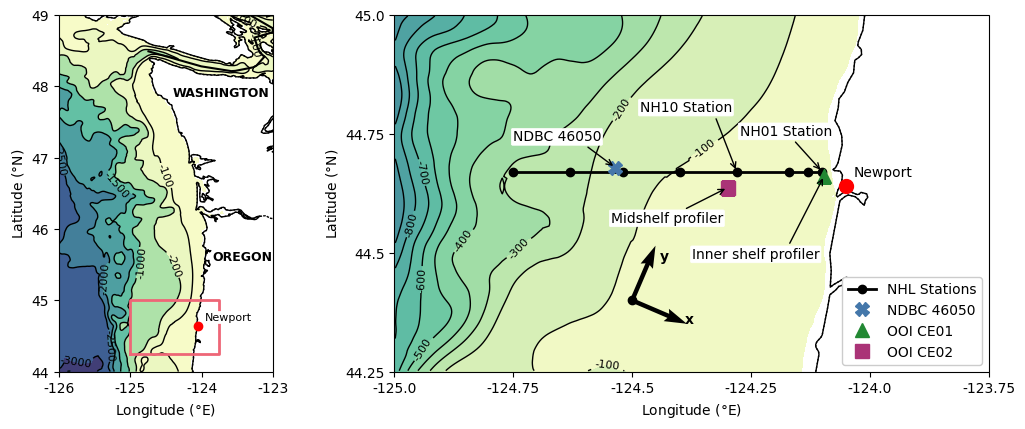

In [10]:
lat_min, lat_max = 44.25, 45
lon_min, lon_max = -125, -123.75

region_lon_min, region_lon_max = -126, -123
region_lat_min, region_lat_max = 44, 49

aspect_1 = (region_lon_max - region_lon_min) / (region_lat_max - region_lat_min)
aspect_2 = (lon_max - lon_min) / (lat_max - lat_min)
width_ratio = aspect_2 / aspect_1

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
    gridspec_kw={"width_ratios": [1, width_ratio], "wspace": 0.3},
)

ax1 = cast("GeoAxes", ax1)
ax1.set_extent([region_lon_min, region_lon_max, region_lat_min, region_lat_max], crs=ccrs.PlateCarree())

deep_contours = np.concatenate((np.arange(-4000, -500, 500), np.arange(-200, -50, 100)))
ctr = ax1.contour(
    bathy["lon"].sel(lon=slice(region_lon_min, region_lon_max)),
    bathy["lat"].sel(lat=slice(region_lat_min, region_lat_max)),
    bathy["elevation"].sel(lat=slice(region_lat_min, region_lat_max), lon=slice(region_lon_min, region_lon_max)),
    transform=ccrs.PlateCarree(),
    levels=deep_contours,
    colors="k",
    linewidths=1,
    linestyles="solid",
)

plt.clabel(ctr, levels=deep_contours, inline=True, fmt="%d", fontsize=8)

ax1.contourf(
    bathy["lon"],
    bathy["lat"],
    bathy["elevation"],
    cmap=cmo.deep_r,
    levels=np.concatenate((deep_contours, [0])),
    transform=ccrs.PlateCarree(),
)

ax1.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    color="#EE6677",
    linestyle="-",
    linewidth=2,
)

ax1.plot(
    NEWPORT["lon"],
    NEWPORT["lat"],
    color="red",
    marker="o",
    linestyle="None",
    markersize=6,
    transform=ccrs.PlateCarree(),
)

ax1.annotate(
    "WASHINGTON",
    xy=(-124.5, 48.5),
    xytext=(-124.4, 48),
    arrowprops=None,
    fontsize=9,
    verticalalignment="top",
    horizontalalignment="left",
    transform=ccrs.PlateCarree(),
    fontweight="bold",
)

ax1.annotate(
    "OREGON",
    xy=(-124.5, 46.5),
    xytext=(-123.85, 45.7),
    arrowprops=None,
    fontsize=9,
    verticalalignment="top",
    horizontalalignment="left",
    transform=ccrs.PlateCarree(),
    fontweight="bold",
)

ax1.annotate(
    "Newport",
    xy=(NEWPORT["lon"], NEWPORT["lat"]),
    xytext=(NEWPORT["lon"] + 0.1, NEWPORT["lat"] + 0.05),
    arrowprops=None,
    fontsize=8,
    bbox={"boxstyle": "round,pad=0.1", "fc": "white", "ec": "white", "lw": 0.5},
    verticalalignment="bottom",
    horizontalalignment="left",
    transform=ccrs.PlateCarree(),
)

ax1.set_xticks(np.arange(region_lon_min, region_lon_max + 0.1, 1), crs=ccrs.PlateCarree())
ax1.set_yticks(np.arange(region_lat_min, region_lat_max + 0.1, 1), crs=ccrs.PlateCarree())
ax1.set_xticklabels([])
ax1.set_yticklabels([])

ax1.set_xlabel("Longitude ($\\degree$E)")
lon_formatter = LongitudeFormatter()
ax1.xaxis.set_major_formatter(lon_formatter)
ax1.set_xticklabels([f"{lon:.0f}" for lon in np.arange(region_lon_min, region_lon_max + 0.1, 1)])

ax1.set_ylabel("Latitude ($\\degree$N)")
lat_formatter = LatitudeFormatter()
ax1.yaxis.set_major_formatter(lat_formatter)
ax1.set_yticklabels([f"{lat:.0f}" for lat in np.arange(region_lat_min, region_lat_max + 0.1, 1)])
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle="-", linewidth=1.5)
ax1.add_feature(cfeature.STATES, linestyle=":")

ax2 = cast("GeoAxes", ax2)
ax2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ctr = ax2.contour(
    bathy["lon"].sel(lon=slice(lon_min, lon_max)),
    bathy["lat"].sel(lat=slice(lat_min, lat_max)),
    bathy["elevation"].sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)),
    transform=ccrs.PlateCarree(),
    levels=np.arange(-2000, -50, 100),
    colors="k",
    linewidths=1,
    linestyles="solid",
)

plt.clabel(ctr, levels=np.arange(-800, -50, 100), inline=True, fmt="%d", fontsize=8)

ax2.contourf(
    bathy["lon"],
    bathy["lat"],
    bathy["elevation"],
    cmap=cmo.deep_r,
    levels=np.arange(-2000, 50, 100),
    transform=ccrs.PlateCarree(),
)

ax2.plot(
    station_positions["lon"],
    station_positions["lat"],
    color="#000000",
    marker="o",
    linestyle="-",
    markersize=6,
    linewidth=2,
    transform=ccrs.PlateCarree(),
    label="NHL Stations",
)

ax2.plot(
    NDBC_46050["lon"],
    NDBC_46050["lat"],
    color="#4477AA",
    marker="X",
    linestyle="None",
    markersize=10,
    transform=ccrs.PlateCarree(),
    label="NDBC 46050",
)

ax2.plot(
    CE01ISSP["lon"],
    CE01ISSP["lat"],
    color="#228833",
    marker="^",
    linestyle="None",
    markersize=10,
    transform=ccrs.PlateCarree(),
    label="OOI CE01",
)

ax2.plot(
    CE02SHSP["lon"],
    CE02SHSP["lat"],
    color="#AA3377",
    marker="s",
    linestyle="None",
    markersize=10,
    transform=ccrs.PlateCarree(),
    label="OOI CE02",
)

ax2.plot(
    NEWPORT["lon"],
    NEWPORT["lat"],
    color="red",
    marker="o",
    linestyle="None",
    markersize=10,
    transform=ccrs.PlateCarree(),
)

nh10 = station_positions.loc[station_positions["station"] == "NH10"].squeeze()
nh10 = cast("pd.Series", nh10)  # satisfy type checker
ax2.annotate(
    "NH10 Station",
    xy=(nh10["lon"], nh10["lat"]),
    xytext=(nh10["lon"] - 0.01, nh10["lat"] + 0.15),
    arrowprops={"arrowstyle": "->", "relpos": (0.75, 1)},
    bbox={"boxstyle": "round,pad=0.1", "fc": "white", "ec": "white", "lw": 0.5},
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    transform=ccrs.PlateCarree(),
)

nh01 = station_positions.loc[station_positions["station"] == "NH01"].squeeze()
nh01 = cast("pd.Series", nh01)  # satisfy type checker
ax2.annotate(
    "NH01 Station",
    xy=(nh01["lon"], nh01["lat"]),
    xytext=(nh01["lon"] + 0.02, nh01["lat"] + 0.1),
    arrowprops={"arrowstyle": "->"},
    bbox={"boxstyle": "round,pad=0.1", "fc": "white", "ec": "white", "lw": 0.5},
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    transform=ccrs.PlateCarree(),
)

ax2.annotate(
    "Inner shelf profiler",
    xy=(CE01ISSP["lon"], CE01ISSP["lat"]),
    xytext=(CE01ISSP["lon"] - 0.01, CE01ISSP["lat"] - 0.18),
    arrowprops={"arrowstyle": "->", "relpos": (0.75, 1)},
    bbox={"boxstyle": "round,pad=0.1", "fc": "white", "ec": "white", "lw": 0.5},
    fontsize=10,
    verticalalignment="bottom",
    horizontalalignment="right",
    transform=ccrs.PlateCarree(),
)

ax2.annotate(
    "Midshelf profiler",
    xy=(CE02SHSP["lon"], CE02SHSP["lat"]),
    xytext=(CE02SHSP["lon"] - 0.01, CE02SHSP["lat"] - 0.05),
    arrowprops={"arrowstyle": "->"},
    bbox={"boxstyle": "round,pad=0.1", "fc": "white", "ec": "white", "lw": 0.5},
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    transform=ccrs.PlateCarree(),
)

ax2.annotate(
    "NDBC 46050",
    xy=(NDBC_46050["lon"], NDBC_46050["lat"]),
    xytext=(NDBC_46050["lon"] - 0.03, NDBC_46050["lat"] + 0.05),
    arrowprops={"arrowstyle": "->", "relpos": (0.8, 0)},
    bbox={"boxstyle": "round,pad=0.1", "fc": "white", "ec": "white", "lw": 0.5},
    fontsize=10,
    verticalalignment="bottom",
    horizontalalignment="right",
    transform=ccrs.PlateCarree(),
)

ax2.annotate(
    "Newport",
    xy=(NEWPORT["lon"], NEWPORT["lat"]),
    xytext=(NEWPORT["lon"] + 0.015, NEWPORT["lat"] + 0.015),
    arrowprops=None,
    fontsize=10,
    verticalalignment="bottom",
    transform=ccrs.PlateCarree(),
)

ax2.set_xticks(np.arange(lon_min, lon_max + 0.1, 0.25), crs=ccrs.PlateCarree())
ax2.set_yticks(np.arange(lat_min, lat_max + 0.1, 0.25), crs=ccrs.PlateCarree())
ax2.set_xticklabels([])
ax2.set_yticklabels([])

ax2.set_xlabel("Longitude ($\\degree$E)")
lon_formatter = LongitudeFormatter()
ax2.xaxis.set_major_formatter(lon_formatter)
ax2.set_xticklabels(np.arange(lon_min, lon_max + 0.1, 0.25))

ax2.set_ylabel("Latitude ($\\degree$N)")
lat_formatter = LatitudeFormatter()
ax2.yaxis.set_major_formatter(lat_formatter)
ax2.set_yticklabels(np.arange(lat_min, lat_max + 0.1, 0.25))


ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle="-", linewidth=1.5)
ax2.add_feature(cfeature.STATES, linestyle=":")

ax2.legend(loc="lower right", framealpha=1)

x_tail = 0.1
y_tail = 0.7
x_head = 0.9
y_head = 0.8
dx = 0.1
dy = 0

# arrow = mpatches.Arrow(x_tail, y_tail, dx, dy, transform=ax2.transAxes, width=0.03, rotation=34, color="black")
# rotated_arrow = arrow

# ax2.add_artist(arrow)
# # ax2.add_artist(rotated_arrow)

# ax2.quiver(
#     -124.5, 44.3, 0, 1,
# )
# ax2.quiver(
#     -124.5, 44.3, 1, 0,
# )

theta = -np.deg2rad(float(velocity.attrs["theta"]))
coordinate_x = -124.5
coordinate_system_origin = {
    "lon": -124.5,
    "lat": 44.4,
}
scale = 10
ax2.quiver(
    coordinate_system_origin["lon"],
    coordinate_system_origin["lat"],
    np.cos(theta),
    np.sin(theta),
    scale=scale,
)
ax2.quiver(
    coordinate_system_origin["lon"],
    coordinate_system_origin["lat"],
    -np.sin(theta),
    np.cos(theta),
    scale=scale,
)
ax2.plot(coordinate_system_origin["lon"], coordinate_system_origin["lat"], "o", c="k")
ax2.annotate(
    "x",
    xy=(
        coordinate_system_origin["lon"] + np.cos(theta) / scale,
        coordinate_system_origin["lat"] + np.sin(theta) / scale,
    ),
    xytext=(10, 0),
    textcoords="offset points",
    fontsize=10,
    va="center",
    ha="center",
    fontweight="bold",
)
ax2.annotate(
    "y",
    xy=(
        coordinate_system_origin["lon"] - np.sin(theta) / scale,
        coordinate_system_origin["lat"] + np.cos(theta) / scale,
    ),
    xytext=(10, 0),
    textcoords="offset points",
    fontsize=10,
    va="center",
    ha="center",
    fontweight="bold",
)

plt.savefig(
    FIGURES_DIR / f"manuscript/{FIG_SAVE_FMT}/study_region_map.{FIG_SAVE_FMT}",
    format=FIG_SAVE_FMT,
    bbox_inches="tight",
    dpi=600,
)